In [1]:
import numpy as np
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests


def fetch_elite_traces_and_reconstructions(
    elites_path="data/ns/elites.json",
    recon_url="http://localhost:4242/reconstruct",
    eval_url="http://localhost:4242/evaluate",
    max_workers_cap=6,
    elite_ids=None,
):
    with open(elites_path, "r") as f:
        elites_data = json.load(f)

    all_elites = elites_data.get("elites", [])
    if elite_ids is None:
        elites = all_elites
    else:
        elite_id_set = set(elite_ids)
        elites = [elite for elite in all_elites if elite.get("id") in elite_id_set]

    def _process_elite(elite):
        elite_id = elite["id"]
        try:
            eval_resp = requests.post(
                eval_url,
                json={
                    "mode": elite["mode"],
                    "id": elite_id,
                    "dataSet": elite["dataSet"],
                    "selectedCells": elite["selectedCells"],
                    "rngMode": elite["rngMode"],
                    "getTraces": True,
                },
                timeout=100,
            )
            eval_resp.raise_for_status()
            eval_data = eval_resp.json()
            fit = eval_data.get("fitness") or {}

            trace_data = {
                "speed_trace": fit.get("speed_trace", None),
                "steer_trace": fit.get("steer_trace", None),
                "brake_trace": fit.get("brake_trace", None),
                "accel_trace": fit.get("accel_trace", None),
            }

            embedding_data = fit.get("embedding_data", None)

            recon_resp = requests.post(
                recon_url,
                json={
                    "mode": elite["mode"],
                    "seed": elite_id,
                    "dataSet": elite["dataSet"],
                    "selectedCells": elite["selectedCells"],
                },
                timeout=10,
            )
            recon_resp.raise_for_status()
            recon_data = recon_resp.json()

            return elite_id, {
                "trace_data": trace_data,
                "track": recon_data.get("track", None),
                "embedding_data": embedding_data,
            }, None
        except Exception as e:
            return elite_id, None, str(e)

    id_to_traces_recon = {}
    max_workers = min(max_workers_cap, max(1, len(elites)))
    print(f"Processing {len(elites)} elites with {max_workers} workers...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_process_elite, elite) for elite in elites]

        for future in as_completed(futures):
            elite_id, payload, err = future.result()
            if err is not None:
                print(f"Error processing elite {elite_id}: {err}")
                continue
            id_to_traces_recon[elite_id] = payload
            print(f"Got reconstruction for elite {elite_id}")

    print(f"Completed: {len(id_to_traces_recon)}/{len(elites)} elites")
    return id_to_traces_recon, elites

elites_ids = [979.8881513794456, 750.49733953105]

id_to_traces_recon, elites = fetch_elite_traces_and_reconstructions(elite_ids=elites_ids)

Processing 2 elites with 2 workers...
Got reconstruction for elite 979.8881513794456
Got reconstruction for elite 750.49733953105
Completed: 2/2 elites


In [2]:
from mapelite.config import PRECOMPILED_EMBEDDINGS_PATH
import umap

from mapelite.data_analysis.utils import project_elites_umap

_data = np.load(PRECOMPILED_EMBEDDINGS_PATH)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(_embeddings)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(_embeddings)

c:\Users\milob\Documents\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# check keys of elite[0]

from mapelite.evaluator import EvaluatorMetrics
from mapelite.config import EMBEDDING_MODEL_PATH
import copy

evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def perturb_speed(original_embedding_data, perturbation_factor=1.1):
    embedding_data = copy.deepcopy(original_embedding_data)
    if embedding_data is None:
        return None
    
    speed_column_idx = 1
    perturb_row = 20
    embedding_data[perturb_row][speed_column_idx] = embedding_data[perturb_row][speed_column_idx] * perturbation_factor 
    return embedding_data

embedding_data = id_to_traces_recon[979.8881513794456]["embedding_data"]
perturbd_embedding_data = perturb_speed(embedding_data)
print(embedding_data)
print(perturbd_embedding_data)

embedding = evaluator.measure_from_metrics(embedding_data)
embedding_bis = evaluator.measure_from_metrics(embedding_data)
perturbd_embedding = evaluator.measure_from_metrics(perturbd_embedding_data)

print(embedding)
print(embedding_bis)

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_1.pth...
Model loaded with latent_dim=32
[[0, 39.9992, -0.445158, 0.783175, 0, 3, 3.07104], [1, 40.5798, 1, 1, 0, 3, 2.16092], [2, 38.9638, -0.935759, 0, 0.211077, 3, 0.451111], [3, 37.3094, -0.0434995, 0.400034, 0, 3, 0.366211], [4, 37.6533, 0.152341, 0.888643, 0, 3, 1.51985], [5, 38.0873, -1, 1, 0, 3, 3.60071], [6, 37.2772, 0.189645, 0, 0.038673, 3, 6.37079], [7, 36.413, -0.112342, 0, 0.0410448, 3, 8.3993], [8, 35.6478, -0.118276, 0, 0.0363723, 3, 9.89408], [9, 34.8179, -0.123916, 0, 0.0377763, 3, 11.0462], [10, 33.7461, -0.0951042, 0, 0.335951, 3, 11.5059], [11, 31.1278, -0.0769056, 0, 0.331155, 3, 11.3787], [12, 29.3811, -0.152129, 0, 0.348523, 3, 11.3079], [13, 27.5169, -0.270057, 0, 0.0107974, 2, 11.4821], [14, 25.9209, -0.926848, 0, 0.00514394, 2, 12.0202], [15, 24.3991, -0.937687, 0, 0.00603058, 2, 12.9994], [16, 22.7982, -0.314806, 0, 0.0118866, 2, 14.3526], [17, 21.7493, 0.432001, 0,

Elite ID 979.8881513794456 UMAP 2D coords: [ 4.4490485 -2.8786616]
Elite ID 979.8881513794456 UMAP 2D coords: [ 4.3317556 -2.9617505]


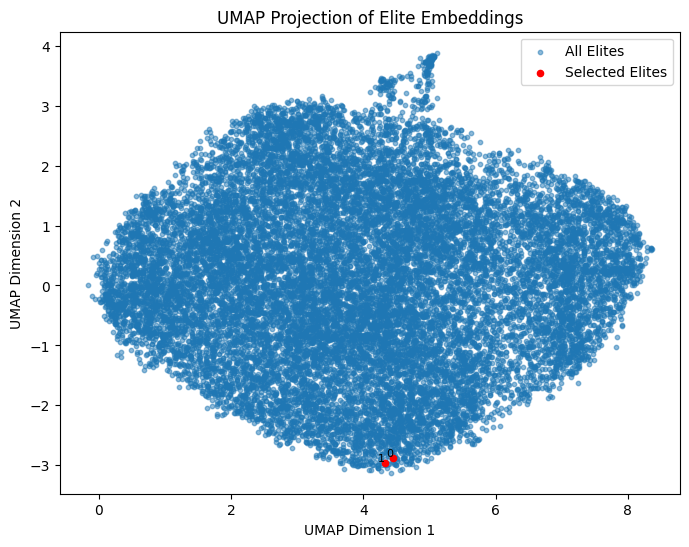

{'selected_elites': [{'id': 979.8881513794456,
   'embedding': array([-0.451455  , -1.211203  , -0.781036  ,  0.38649222,  0.43917638,
          -1.0007153 , -0.18866688,  0.430685  , -0.6915997 , -1.6488937 ,
           0.64613384, -0.18383701,  0.33031768,  1.2745874 , -0.08200894,
          -0.27722174, -0.21247368,  0.9223234 , -0.6674397 , -0.28461465,
           0.27472913, -0.28489035,  0.04871442,  0.0741595 ,  0.22989182,
           0.6654412 , -0.00340749,  0.6556827 ,  1.1410625 ,  0.73419005,
           0.862032  , -0.08394123], dtype=float32)},
  {'id': 979.8881513794456,
   'embedding': array([-0.32596523, -1.3849832 , -0.7857778 ,  0.5066274 ,  0.26408422,
          -0.9740841 ,  0.03036287,  0.3961713 , -0.49016607, -1.6899997 ,
           0.38286605,  0.0660428 ,  0.742458  ,  1.1971465 , -0.20385167,
          -0.5029869 ,  0.10984863,  1.0351208 , -0.66965824, -0.19990048,
           0.1796076 , -0.17719813,  0.01025239, -0.00258675,  0.24461068,
           0.7223722

In [4]:
elite1 = {
    "id": 979.8881513794456,
    "embedding": embedding,
}
elite2 = {
    "id": 979.8881513794456,
    "embedding": perturbd_embedding,
}

project_elites_umap([elite1, elite2], umap_model, umap_embeddings)

Rendering 2 elites across 1 figure(s)...


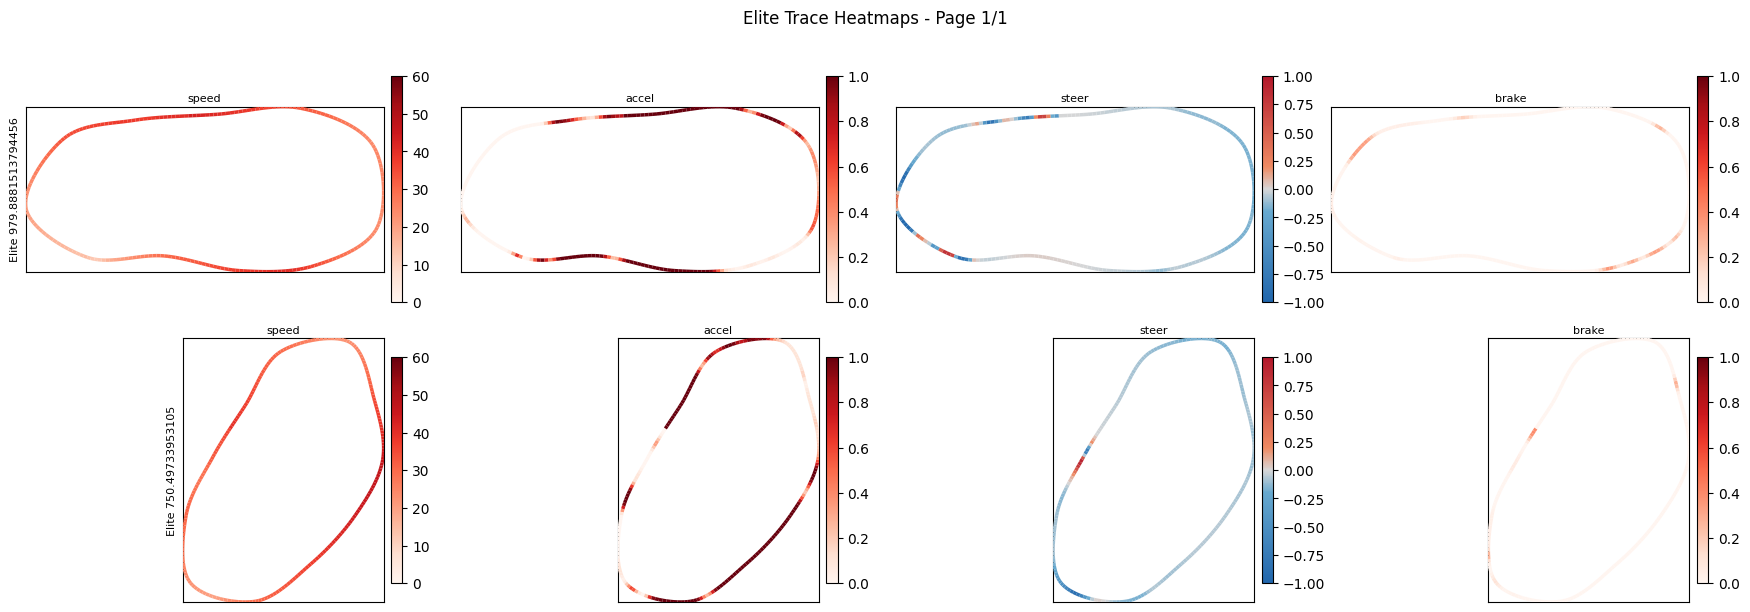

In [5]:
import numpy as np
import importlib
import math
import mapelite.data_analysis.utils
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

importlib.reload(mapelite.data_analysis.utils)

from mapelite.data_analysis.utils import (
    plot_track,
    plot_track_heatmap,
)

# Keep the same metric ordering and fixed ranges used in mapelite/embeddings/visualizer.py
TRACE_METRICS = ["speed_trace", "accel_trace", "steer_trace", "brake_trace"]
TRACE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
}

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

# Use red heatmap for all traces except steer_trace.
TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
}

ROWS_PER_FIGURE = 5

def _clean_trace(trace):
    if not trace:
        return []
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return []
    values = arr[:, 0]
    distances = arr[:, 1]
    finite = np.isfinite(values) & np.isfinite(distances)
    values, distances = values[finite], distances[finite]
    if len(values) < 2:
        return []
    return list(zip(values.tolist(), distances.tolist()))

elite_items = list(id_to_traces_recon.items())
if len(elite_items) == 0:
    print("No elites found in id_to_traces_recon. Run Cell 1 first.")
else:
    ncols = len(TRACE_METRICS)
    total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
    print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

    for page_num in range(total_pages):
        start_idx = page_num * ROWS_PER_FIGURE
        page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
        nrows = len(page)

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.1 * nrows), squeeze=False)

        for r, (elite_id, content) in enumerate(page):
            track = content.get("track", None)
            trace_data = content.get("trace_data", {})

            for c, metric in enumerate(TRACE_METRICS):
                ax = axes[r, c]
                metric_trace = _clean_trace(trace_data.get(metric, None))

                metric_label = metric.replace("_trace", "")
                title = f"{metric_label}"

                if track and metric_trace:
                    plot_track_heatmap(
                        ax,
                        track,
                        metric_trace,
                        title=title,
                        cmap=TRACE_CMAPS.get(metric, "Reds"),
                        color_range=TRACE_RANGES.get(metric),
                    )
                else:
                    if track:
                        plot_track(ax, track, title=title, track_color="lightgray")
                    else:
                        ax.set_axis_off()
                    ax.text(0.5, 0.5, "missing data", ha="center", va="center", transform=ax.transAxes, fontsize=8)

                if c == 0:
                    ax.set_ylabel(f"Elite {elite_id}", fontsize=8)

        fig.suptitle(f"Elite Trace Heatmaps - Page {page_num + 1}/{total_pages}", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

Rendering 2 elites across 1 figure(s)...


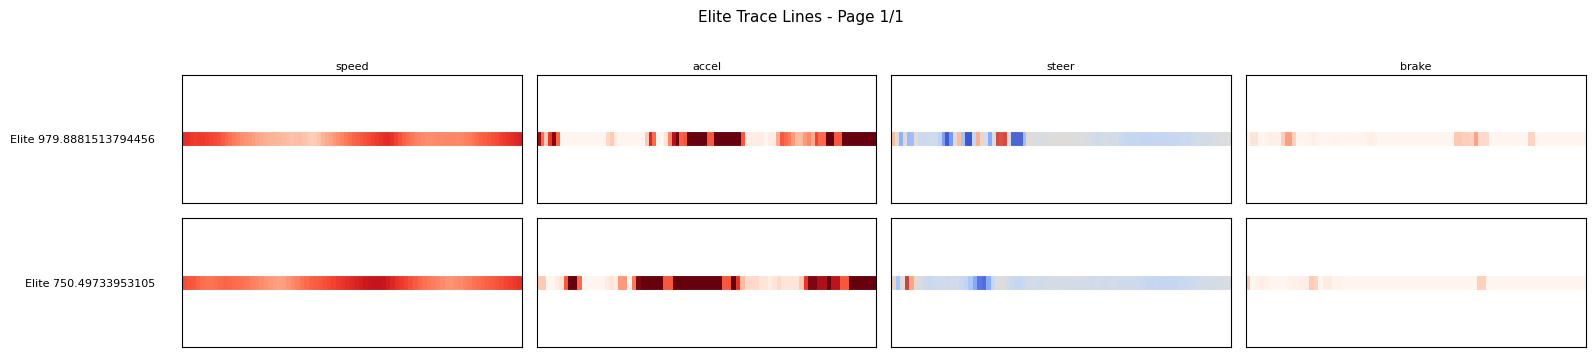

In [6]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt

import mapelite.data_analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from mapelite.data_analysis.utils import plot_trace_fixed_line

TRACE_METRICS = ["speed_trace", "accel_trace", "steer_trace", "brake_trace"]
TRACE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
}
TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": "coolwarm",
    "brake_trace": "Reds",
}

ROWS_PER_FIGURE = 8

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

if "id_to_traces_recon" not in globals():
    print("id_to_traces_recon is not available. Run Cell 1 first.")
else:
    elite_items = list(id_to_traces_recon.items())
    if len(elite_items) == 0:
        print("No elites found in id_to_traces_recon. Run Cell 1 first.")
    else:
        ncols = len(TRACE_METRICS)
        total_pages = math.ceil(len(elite_items) / ROWS_PER_FIGURE)
        print(f"Rendering {len(elite_items)} elites across {total_pages} figure(s)...")

        for page_num in range(total_pages):
            start_idx = page_num * ROWS_PER_FIGURE
            page = elite_items[start_idx : start_idx + ROWS_PER_FIGURE]
            nrows = len(page)

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
                squeeze=False,
            )

            for r, (elite_id, content) in enumerate(page):
                trace_data = content.get("trace_data", {})

                for c, metric in enumerate(TRACE_METRICS):
                    ax = axes[r, c]
                    values = _extract_trace_values(trace_data.get(metric, None))
                    title = metric.replace("_trace", "")

                    if values.size >= 2:
                        plot_trace_fixed_line(
                            ax,
                            values,
                            line_length=1.0,
                            y=0.0,
                            title=title if r == 0 else None,
                            cmap=TRACE_CMAPS.get(metric, "Reds"),
                            color_range=TRACE_RANGES.get(metric),
                            linewidth=10,
                            show_colorbar=False,
                        )
                    else:
                        ax.set_axis_off()
                        if r == 0:
                            ax.set_title(title, fontsize=8, pad=4)
                        ax.text(
                            0.5,
                            0.5,
                            "missing data",
                            ha="center",
                            va="center",
                            transform=ax.transAxes,
                            fontsize=7,
                        )

                    if c == 0:
                        ax.text(
                            -0.08,
                            0.5,
                            f"Elite {elite_id}",
                            transform=ax.transAxes,
                            ha="right",
                            va="center",
                            fontsize=8,
                        )

            fig.suptitle(f"Elite Trace Lines - Page {page_num + 1}/{total_pages}", fontsize=11)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()